# Introduction à Python pour la Data Science

## TP 3 : Introduction à Pandas

### Objectifs

À l’issue de ce TP, vous devrez être capable de :

- créer, importer et inspecter un `DataFrame` ;
- raisonner sur l’index, les colonnes et les `dtype` ;
- sélectionner des données avec `loc`, `iloc` et des `boolean masks` ;
- nettoyer des valeurs manquantes et convertir des types ;
- effectuer des transformations vectorisées ;
- agréger des données avec `groupby`, `agg`, `transform` et `pivot_table` ;
- combiner plusieurs sources avec `concat` et `merge` ;
- contrôler la cardinalité et la qualité d’une jointure ;
- construire un pipeline d’analyse reproductible.

## 1 **Introduction**

Depuis une dizaine d’années, le package `Pandas` s’impose comme l’une des composantes essentielles de l’écosystème de la data science. Avant son apparition, le DataFrame, structure centrale dans des langages comme `R` ou `Stata`, manquait cruellement à l’univers `Python`. Pourtant, grâce à `NumPy`, les fondations nécessaires existaient déjà, il ne manquait qu’une réorganisation adaptée aux besoins des data scientists.

`Pandas`, développé par **Wes McKinney**, à comblé ce manque. C'est une bibliothèque offrant une structure de donnée dédiées, le `DataFrame`. Ce projet a marqué un tournant majeur pour l’analyse de données en `Python` et explique aujourd’hui la place dominante de `Pandas` dans l’écosystème de la data science.

`Pandas` est une librairie Python spécialisée dans la manipulation de données tabulaires. Elle repose en grande partie sur NumPy, mais ajoute :

- des index explicites ;
- des colonnes nommées ;
- des `dtype` potentiellement différents selon les colonnes ;
- des méthodes de lecture et d’écriture ;
- des opérations de filtrage, d’agrégation et de jointure proches de SQL ;
- une gestion intégrée des valeurs manquantes.

Documentation officielle : [Pandas documentation](https://pandas.pydata.org/docs/)

### 1.1 Données

Les données choisies pour illustrer ce tutoriel sont issues d'une compétition du site [Kaggle](https://www.kaggle.com/): [Titanic: Machine learnic from Disaster](https://www.kaggle.com/c/titanic-gettingStarted). Le concours est terminé mais les [données](https://www.kaggle.com/c/titanic-gettingStarted/data) sont toujours disponibles sur le site avec des tutoriels utilisant Excel, Python ou R.

### 1.2 Environnement

Nous suivrons les conventions habituelles dans l’import des packages :

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Pour obtenir des résultats reproductibles, on peut fixer la racine du générateur pseudo-aléatoire.

In [ ]:
np.random.seed(42)

## 2 **Pandas et sa logique**

### 2.1 Le DataFrame Pandas

L’élément central de la logique de `Pandas` est le `DataFrame`. Il s’agit d’une structure de données bidimensionnelle, organisée en lignes et colonnes. Contrairement à une matrice, les colonnes d’un `DataFrame` peuvent contenir des types de données différents, offrant ainsi une grande flexibilité pour la manipulation et l’analyse des données.

On se repère dans un `DataFrame` à l'aide des éléments suivant :

- l'indice de la ligne;
- le nom de la colonne;
- la valeur de la donnée.

![Image](https://minio.lab.sspcloud.fr/lgaliana/python-ENSAE/inputs/merge_pandas/pandasDF.png)

*Source : [Python pour la data science](https://pythonds.linogaliana.fr/content/manipulation/02_pandas_intro.html#logique-de-pandas)*

Dans la pratique, il s'agit d'un tableau bi-dimensionnel avec des index de lignes et de colonnes mais il peut également être vu comme une liste de `Series` partageant le même index. L'index de colonne (noms des variables) est un objet de type `dict` (dictionnaire). C'est la classe qui sera principalement utilisée dans ce tutoriel.

### 2.2 La Series Pandas

Le `DataFrame` que l'on a vu juste avant est en réalité une collection d'un objet appelées `pandas.Series`. Ces `Series` sont des objets unidimensionnels, qui constituent une extension des arrays unidimensionnels de `NumPy`.

Pour faciliter le traitement des données catégorielles ou temporelles, `Pandas` propose des types de variables supplémentaires par rapport à `NumPy`, tels que `categorical`, `datetime64` et `timedelta64`. Ces types spécifiques sont associés à des méthodes optimisées, permettant une manipulation plus efficace et intuitive de ce genre de données.

Par ailleurs, une `pandas.Series` peut adopter plusieurs types de données, en extension de ceux disponibles nativement en `Python`. Le type d’une variable détermine son comportement et les opérations possibles : en effet, une opération peut avoir un sens pour une valeur numérique, mais pas nécessairement pour une valeur textuelle ou catégorielle.

### 2.3 Principe de _tidy Data_

<p>Le concept de <strong><em>tidy</em></strong> data, popularisé par Hadley Wickham via ses packages <code>R</code>,
est parfaitement pertinent pour décrire la structure d’un <em>DataFrame</em> <code>Pandas</code>.
Les trois règles des données <em>tidy</em> sont les suivantes :</p>
<ul>
<li>Chaque <strong>variable</strong> possède sa propre colonne ;</li>
<li>Chaque <strong>observation</strong> possède sa propre ligne ;</li>
<li>Une <strong>valeur</strong>, matérialisant une observation d’une variable,
se trouve sur une unique cellule.</li>
</ul>

![Image](https://perso.esiee.fr/~courivad/R/_images/09-dataframes-fig12.png)

*Source : [R & Data Visualisation](https://perso.esiee.fr/~courivad/R/fr-12-transforming.html)*

Ces principes peuvent vous apparaître de bon sens mais vous découvrirez que de nombreux formats de données ne correspondent pas à ce principe. Par exemple, des tableurs Excel proposent régulièrement des valeurs à cheval sur plusieurs colonnes ou plusieurs lignes fusionnées. Restructurer cette donnée selon le principe des tidy data sera un enjeu pour être en mesure d’effectuer des traitements sur celle-ci.

> **Rappel — granularité, schéma et index**
>
> Avant toute manipulation, il faut expliciter ce que représente une ligne du `DataFrame`. Cette granularité détermine les clés possibles, les agrégations pertinentes et le sens des doublons.
>
> Un `DataFrame` possède également un schéma implicite :
>
> - le nom des colonnes ;
> - leur `dtype` ;
> - les contraintes d’unicité ;
> - les valeurs manquantes autorisées ;
> - les unités et modalités attendues.
>
> L’index participe à l’alignement automatique des objets Pandas. Deux `Series` sont alignées sur leurs labels lors d’une opération, même si leurs valeurs ne sont pas dans le même ordre.

## 3 **Création et manipulation de base d'un DataFrame**

### 3.1 Création

La création d’un `DataFrame` peut se faire de différentes manières. La méthode la plus courante consiste à partir d’un dictionnaire de listes, ouù chaque clé représente le nom d’une colonne et chaque liste associée contient les valeurs correspondantes.

In [ ]:
data = {"state": ["Ohio", "Ohio", "Ohio",
       "Nevada", "Nevada"],
     "year": [2000, 2001, 2002, 2001, 2002],
     "pop": [1.5, 1.7, 3.6, 2.4, 2.9]}
dataframe = pd.DataFrame(data)
dataframe

### 3.2 Indexation

La différence essentielle entre une `Series` et un objet `NumPy` est l’indexation. Dans un `NumPy array`, les éléments sont accessibles uniquement par leur position (entier). Dans une `Series` ou un `DataFrame`, chaque élément est accessible via un indice de position mais aussi via un index, souvent plus explicite.

Ceci permet d’accéder à la donnée de manière plus naturelle, en utilisant les noms de colonne par exemple:

> **Rappel — `loc`, `iloc` et copies**
>
> - `loc` sélectionne à partir des labels ;
> - `iloc` sélectionne à partir des positions ;
> - un `boolean mask` doit être aligné sur l’index ;
> - `.copy()` permet de créer explicitement un sous-ensemble indépendant.
>
> Pour modifier une partie d’un `DataFrame`, on privilégie :
>
> ```python
> df.loc[condition, "colonne"] = valeur
> ```
>
> Cette écriture évite les affectations chaînées et le `SettingWithCopyWarning`.

In [ ]:
dataframe["state"]

La présence d’indices rend le subsetting (_i.e._ la sélection de lignes ou de colonnes) particulièrement simple. Les `DataFrames` disposent en effet de deux types d’indices : ceux des lignes et ceux des colonnes. Il est donc possible d’effectuer des sélections selon ces deux dimensions. Comme on le verra dans les exercices suivants, cette structure facilite grandement la sélection de lignes.

In [ ]:
dataframe.loc[dataframe["state"] == "Ohio"]

On peut voir sur la gauche l’affichage du numéro de la ligne, il s’agit ici de l’indice par défaut pour la dimension des lignes, puisque nous n’en avons pas défini un nous-mêmes. Bien que la définition d’un indice ne soit pas obligatoire, il est tout à fait possible d’en utiliser un correspondant à une variable d’intérêt (nous verrons cela plus en détail lors de l’étude de `groupby` dans le prochain chapitre). Cependant, cette approche peut s’avérer trompeuse ; il est donc conseillé de ne l’utiliser que de manière temporaire et de procéder régulièrement à un reset_index() pour revenir à une structure plus claire.


## 4 **Lecture et écriture des données**

S’il fallait créer à la main tous ses DataFrames à partir de vecteurs ou de dictionnaire, Pandas ne serait pas pratique. Pandas propose de nombreuses fonctions pour lire des données stockées dans des formats différents (csv, texte, fixe, compressé, xml, html, hdf5, ...). Dans ce cours, nous allons nous contenté de décrire les fonctions les plus utiles `read_csv` et `read_table` pour lire des fichiers textes et générer un objet de classe ` DataFrame`.

<details open style="border: 2px solid #2196F3; border-radius: 8px; margin: 16px 0;">
  <summary style="background: #E3F2FD; padding: 8px 12px; font-weight: bold; color: #0D47A1; cursor: pointer;">
    💡Remarque
  </summary>
  <div style="padding: 12px;">
   En principe ces fonctions font appel à un code écrit en C dont très rapide à l'exécution à l'exeption de certaines options qui provoquent une exécution en Python (<code>engine=Python</code>). 
  </div>
</details>

### 4.1 Exemple pratique : Titanic

Comme dit plus haut, les données utilisées dans ce tutoriel proviennent de [Titanic: Machine learnic from Disaster](https://www.kaggle.com/c/titanic-gettingStarted). Le Titanic est l'un des paquebots les plus célèbres de l'histoire. Lors de son voyage inaugural en avril 1912, il a heurté un iceberg et a coulé dans l'Atlantique Nord, entraînant la mort de nombreux passagers et membres d'équipage.

Une des raisons du drame, qui provoqua la mort de 1502 personnes sur les 2224 passagers et membres d'équipage, fut le manque de canots de sauvetage. Il apparaît que les chances de survie dépendaient de différents facteurs (sexe, âge, classe...). Le but du concours était de construire un modèle de prévision (classification supervisée) de survie en fonction de ces facteurs. Les données sont composées d'un échantillon d'apprentissage (891) et d'un échantillon test (418) chacun décrit par 11 variables dont la première indiquant la survie ou non lors du naufrage.

<!-- Vous trouverez ci-dessous la liste des variables du dataset.

Label  | Intitulé
----------|-------------
survival   |     Survival (0 = No; 1 = Yes)
pclass   |       Passenger Class (1 = 1st; 2 = 2nd; 3 = 3rd)
name    |       Name
sex     |        Sex
age     |        Age
sibsp   |        Number of Siblings/Spouses Aboard
parch    |       Number of Parents/Children Aboard
ticket   |       Ticket Number
fare    |        Passenger Fare
cabin   |        Cabin
embarked |       Port of Embarkation (C = Cherbourg; Q = Queenstown; S = Southampton) -->

> **Rappel — contrôler l’import**
>
> Après un `read_csv` ou un `read_excel`, il faut vérifier :
>
> 1. la `shape` ;
> 2. les noms de colonnes ;
> 3. les `dtype` inférés ;
> 4. les valeurs manquantes ;
> 5. les doublons ;
> 6. les unités et le séparateur décimal.
>
> Pour des fichiers volumineux, `usecols`, `dtype`, `parse_dates` et `chunksize` permettent de limiter la mémoire utilisée et de fiabiliser le schéma.


## 5 **Exploration d'un DataFrame**

Pandas adopte une structure de données familière pour les utilisateurs de logiciels statistiques tels que `R` en s’inspirant lui aussi fortement de la logique `SQL`.
La philosophie reste similaire : on réalise des opérations de sélection de lignes ou de colonnes, des tris basés sur les valeurs de certaines variables, ainsi que des traitements standardisés sur ces variables. De manière générale, Pandas encourage l’utilisation des noms de variables plutôt que des indices de lignes ou de colonnes, afin de rendre les manipulations plus explicites et cohérentes.

Pandas offre un très large éventail de fonctionnalités déjà intégrées. Avant de coder une fonction manuellement, il est donc fortement conseillé de vérifier si une implémentation native n’existe pas déjà dans NumPy, Pandas ou une autre bibliothèque. Dans la majorité des cas, il est préférable d’utiliser ces solutions existantes, car elles sont plus optimisées et performantes que celles développées manuellement.

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df

<details open style="border: 2px solid #2196F3; border-radius: 8px; margin: 16px 0;">
  <summary style="background: #E3F2FD; padding: 8px 12px; font-weight: bold; color: #0D47A1; cursor: pointer;">
    💡Remarque
  </summary>
  <div style="padding: 12px;">
   On peut utiliser les methodes <code>df.head()</code> et <code>df.tail()</code> pour afficher respectivement les premières et dernières lignes du DataFrame.
  </div>
</details>

### 5.1 Dimensions et structure des données

La première étape dans l’exploration d’un `DataFrame` consiste à examiner certains de ses attributs et ses dimensions. Les attributs `axes`, `columns` et `index` permettent d’accéder aux informations relatives aux lignes et aux colonnes du `DataFrame`. Les attributs `ndim`, `shape` et `size` fournissent des informations sur la structure globale du `DataFrame`, telles que le nombre de dimensions, la forme (nombre de lignes et de colonnes) et la taille totale (nombre d’éléments).

In [ ]:
df.axes

In [ ]:
df.columns

In [ ]:
df.index

In [ ]:
df.ndim

In [ ]:
df.shape

In [ ]:
df.size

Pour déterminer le nombre de valeurs uniques d’une variable, on utilise la méthode `nunique()`. Par exemple, pour la variable `Pclass` :

In [ ]:
df['Pclass'].nunique()

### 5.2 Accéder aux colonnes d'un DataFrame

Avec Pandas, pour accéder à une colonne dans son ensemble on peut utiliser la syntaxe suivante :

<ul>
<li> <code>DataFrame['variable']</code> pour renvoyer la variable sous forme de Series. </li>
<li> <code>DataFrame.loc[:,['variable']]</code> pour renvoyer la variable sous forme de DataFrame. </li>
</ul>

Pour accéder à plusieurs colonnes, on utilise la syntaxe suivante :

<ul>
<li> <code>DataFrame[['variable1', 'variable2']]</code> </li>
<li> <code>DataFrame.loc[:,['variable1', 'variable2']]</code> </li>
</ul>

C'est equivalent à `SELECT variable1, variable2 FROM DataFrame` en `SQL`.

## 5.3 Accéder aux lignes d'un DataFrame

Pour accéder aux lignes d'un DataFrame, on utilise principalement deux méthodes : `df.loc` et `df.iloc`.

<ul>
<li> <code>df.iloc</code> permet de sélectionner des lignes en utisant les indices. Il faut faire attention car les indices peuvent être modifiés au cours de la manipulation des données. </li>
<li> <code>df.loc</code> utilise des labels. </li>
</ul>

`iloc` va se référer à l'indexation de 0 à N (avec N égal `df.shape[0]`). De son côté, `loc` va se référer aux valeurs de l'index de `df`.

In [ ]:
df_example = pd.DataFrame(
    {'month': [1, 4, 7, 10], 'year': [2012, 2014, 2013, 2014], 'sale': [55, 40, 84, 31]})
df_example = df_example.set_index('month')
df_example

<details open style="border: 2px solid #4CAF50; border-radius: 8px; margin: 16px 0;">
  <summary style="background: #E8F5E9; padding: 8px 12px; font-weight: bold; color: #0D47A1; cursor: pointer;">
    📝 Exercice 1
  </summary>
  <div style="padding: 12px;">
    <li> Que fait <code>df_example.loc[1, :]</code> ? </li>
    <li> Que fait <code>df_example.iloc[1, :]</code> ? </li>
    <li> Que fait <code>df_example.iloc[:, 1]</code> ? </li>
    <li> Que fait <code>df_example.iloc[1, 1]</code> ? </li>
  </div>
</details>

## 6 **Statistiques descriptives**

`Pandas` intègre de nombreuses méthodes permettant de calculer des statistiques agrégées telles que la somme, le nombre de valeurs uniques, le nombre de valeurs non manquantes, la moyenne, la variance, etc. Parmi ces outils, la méthode `describe()` est la plus générique, car elle fournit un résumé statistique complet des données. Elle fournit toutefois une grande quantité d’informations, ce qui peut parfois rendre leur lecture difficile. Il est donc souvent préférable de se concentrer sur certaines colonnes spécifiques ou de sélectionner les statistiques que l’on souhaite réellement analyser.

> **Rappel — nature des variables**
>
> Une colonne numérique n’est pas nécessairement une variable quantitative continue. Un code de classe, un identifiant ou une modalité encodée par un entier ne doit pas automatiquement être résumé par une moyenne.
>
> Pour auditer rapidement un jeu de données :
>
> ```python
> pd.DataFrame({
>     "dtype": df.dtypes,
>     "n_unique": df.nunique(dropna=False),
>     "n_missing": df.isna().sum(),
>     "missing_rate": df.isna().mean(),
> })
> ```

In [ ]:
df.describe()

In [ ]:
print("Somme :", df['Age'].sum(),"\n","Moyenne :", df['Age'].mean())

`Pandas` nous permet de généraliser le calcul de statistiques à plusieurs colonnes :

In [ ]:
df.loc[:, ['Age', 'Fare']].sum()

In [ ]:
df.loc[:, ['Age', 'Fare']].mean()

Il est possible de généraliser ceci à toutes les colonnes en utilisant le paramètre numeric_only pour sélectionner uniquement les variables pertinentes.

In [ ]:
df.mean(numeric_only = True)

## 7 **Quelques visualisations rapides**

Les tableaux numériques constituent sans doute une source précieuse d’informations pour comprendre la structure d’un jeu de données. Cependant, leur densité rend souvent leur interprétation difficile. Un simple graphique permet, d’un seul regard, de visualiser la distribution des données et d’évaluer le caractère plus ou moins normal d’une observation.

`Pandas` intègre des méthodes graphiques (basé sur matplotlib) de base répondant à ce besoin. Elles s’avèrent très pratiques pour générer rapidement des visualisations, notamment après des manipulations complexes de données.

Il est possible d’appliquer directement la méthode plot() à une Series :

In [ ]:
df['Age'].plot()

C'est exactement la même chose que :

In [ ]:
import matplotlib.pyplot as plt
plt.plot(df.index, df['Age'])
plt.show()

Cette visualisation en série n’a pas vraiment de sens car l’âge n'est pas une variable temporelle. C'est pour cela que l'on préfère souvent utiliser des histogrammes pour visualiser la distribution d'une variable quantitative.

In [ ]:
df['Age'].plot(kind='hist') # ou df['Age'].hist()

Beaucoup d'autres types de graphiques sont disponibles (boxplot, scatter, bar, pie, ...).

## 8 **Les principales manipulations de données**

Les opérations les plus courantes en `SQL` sont synthétisées dans le tableau ci-dessous. Il est utile de les connaître, car de nombreuses syntaxes de manipulation de données s’en inspirent. D’une manière ou d’une autre, ces opérations couvrent l’essentiel des usages liés au traitement et à la transformation des données.

| Opération | SQL | Pandas |
|------------|-----|---------|
| Sélectionner des variables par leur noms | `SELECT` | `df[['var1','var2']]` |
| Sélectionner des observations selon une condition | `FILTER` | `df.loc[df['var1'] > 10]` |
| Trier les observations selon une ou plusieurs variables | `SORT BY` | `df.sort_values(by=['var1','var2'], ascending=[True, False])` |
| Ajouter des variables qui sont fonction d’autres variables | `SELECT *, LOG(var1) AS new_var FROM df` | `df['new_var'] = np.log(df['var1'])` |
| Effectuer une opération par groupe | `GROUP BY` | `df.groupby('var1').mean()` |
| Joindre deux tables (inner join) | `SELECT * FROM table1 INNER JOIN table2 ON table1.id = table2.x` | `table1.merge(table2, left_on='id', right_on='x')` |


### 8.1 Transformer les données

Les opérations de transformation sur les données sont essentielles pour modifier, nettoyer et préparer des données en vue de leur analyse. Les transformations peuvent concerner l’ensemble du DataFrame, des colonnes spécifiques ou des lignes spécifiques.

Pour transformer un DataFrame, il est possible d’utiliser des fonctions vectoriséeses, qui permettent d’appliquer rapidement une opération à l’ensemble des éléments du DataFrame. Cela inclut un certain nombre de méthodes disponibles pour les `Series`, mais aussi les fonctions mathématiques de `NumPy`, etc.

> **Rappel — vectorisation**
>
> Les opérations vectorisées sont généralement préférables à `apply(axis=1)` :
>
> - elles sont plus rapides ;
> - elles expriment plus clairement le calcul ;
> - elles réduisent le risque d’erreurs liées aux boucles.
>
> Avant d’utiliser `apply`, vérifier si le calcul peut être exprimé avec une opération arithmétique, `.str`, `.dt`, `map`, `where`, `mask`, `cut` ou `qcut`.

In [ ]:
df = pd.DataFrame(
    data = {
        "var1": [1.9, 0, np.nan, 4.1, 9.04, np.nan],
        "var2": np.random.randint(-10, 10, 6),
    }
)
df

In [ ]:
np.abs(df)

Parmi les méthodes vectorisées (disponible pour les `Series` aussi), l’une des plus utilisées est `.replace()`, qui permet de remplacer toutes les occurrences d’une valeur donnée par une autre valeur. 

In [ ]:
df.replace(np.nan, 0)

<details open style="border: 2px solid #FF9800; border-radius: 8px; margin: 16px 0;">
  <summary style="background: #FFF3E0; padding: 8px 12px; font-weight: bold; color: #E65100; cursor: pointer;">
    ⚠️ Assignation ou méthodes <em>in place</em> ?
  </summary>
  <div style="padding: 12px;">

  Dans les exemples précedents, on ne modifie pas directement le DataFrame. Pour garder la modification, deux possibilité : l'assignation ou utiliser une methode dites "<em>in place</em>". L'assignation est la plus simple des deux:

  <code>df = df.replace(0, np.nan)</code>

  Pour utiliser une méthode "<em>in place</em>", il faut utiliser l'argument `inplace = True`. Cela permet de modifié directement le DataFrame.

  <code>df = df.replace(0, np.nan, inplace=True)</code>

  En pratique, on préfère ne pas utiliser les opérations `inplace`, car elles ne garantissent pas d'obtenir le même résultat à chaque réexécution d'une cellule. Elles peuvent donc être source d'erreurs et nuire à la reproductibilité des analyses.
    
  </div>
</details>

<details open style="border: 2px solid #2196F3; border-radius: 8px; margin: 16px 0;">
  <summary style="background: #E3F2FD; padding: 8px 12px; font-weight: bold; color: #0D47A1; cursor: pointer;">
    💡Gestion des valeurs manquantes
  </summary>
  <div style="padding: 12px;">

<p>
  La gestion des données manquantes est souvent un point délicat. De nombreuses
  stratégies ont été élaborées, les principales sont décrites dans une
  <a href="http://wikistat.fr/pdf/st-m-app-idm.pdf" target="_blank" rel="noopener noreferrer">
    vignette
  </a>.
  Nous ne décrirons ci-dessous que les plus élémentaires à
  <a href="https://pandas.pydata.org/docs/user_guide/missing_data.html?highlight=missing%20data%20handling#" target="_blank" rel="noopener noreferrer">
    mettre en œuvre
  </a>
  avec <code>pandas</code>.
</p>

<p>
  Il est important de noter que le choix de la méthode de traitement des données
  manquantes peut introduire des biais dans l'analyse, et qu'il n'existe souvent
  pas de « bonne » solution universelle.
</p>

<p>
  Prenons un exemple concret&nbsp;: imaginons un jeu de données de santé provenant
  de plusieurs centres médicaux, dont un centre public (CHU) et cinq cliniques
  privées. Si, lors du prétraitement, vous décidez de supprimer toutes les
  observations comportant des valeurs manquantes, il se peut que les données
  issues du centre public soient <strong>entièrement éliminées</strong>. Les
  dossiers médicaux du secteur public utilisent parfois des systèmes
  d'information plus anciens ou hétérogènes et sont souvent soumis à des
  contraintes administratives ou de confidentialité plus strictes.
</p>

<p>
  Cette suppression introduirait un biais d'échantillonnage, car vous ne
  conserveriez plus que la patientèle issue du secteur privé, généralement plus
  aisée que celle du secteur public. Or,
  <strong>
    le niveau de vie influence la probabilité de contracter certaines maladies
  </strong>.
  Ne pas tenir compte de cette dimension pourrait donc fausser vos conclusions
  et rendre vos résultats non représentatifs de la population dans son ensemble.
</p>

<p>
  Comme indiqué précédemment, il n'existe pas de bonne réponse universelle. Le
  plus important est de prendre en compte tous les biais susceptibles d'avoir
  été introduits lors du prétraitement des données et de les documenter dans
  l'étude afin de produire des analyses pertinentes et aussi objectives que
  possible.
</p>

<p>
  Il est parfois pertinent de supprimer toutes les observations présentant des
  données manquantes lorsque celles-ci sont peu nombreuses et principalement
  regroupées sur certaines lignes ou colonnes à l'aide de la méthode
  <code>dropna</code>.
</p>

<p>
  <code>Pandas</code> permet également, dans le cas d'une variable qualitative,
  de considérer <code>np.nan</code> comme une modalité spécifique ou d'ignorer
  l'observation correspondante.
</p>

Autres stratégies possible:

<ul>
  <li>
    <strong>Cas quantitatif&nbsp;:</strong> une valeur manquante peut être
    imputée par la moyenne ou la médiane (méthode <code>fillna</code>).
  </li>
  <li>
    <strong>Cas d'une série chronologique&nbsp;:</strong> imputation par la
    valeur précédente ou suivante, ou par interpolation linéaire,
    polynomiale ou encore par lissage spline.
  </li>
  <li>
    <strong>Cas qualitatif&nbsp;:</strong> imputation par la modalité la plus
    fréquente ou par une répartition aléatoire selon les fréquences observées
    des différentes modalités.
  </li>
</ul>



  </div>
</details>

Comme dit plus haut, on peut vouloir appliquer nos transformations uniquement à certaines variables (_i.e._ certaines colonnes). Ci-dessous vous trouverez un exemple avec une autre opération fréquente, la méthode `rename()`), à laquelle on passe un dictionnaire qui contient autant de couples clé-valeur que de variables à renommer, et dans lequel chaque couple clé-valeur est de la forme `'ancien_nom'`: `'nouveau_nom'`.

In [ ]:
df = pd.DataFrame(
    data = {
        "var1": [3.3, 5.6, 2.2],
        "var2": ["18", "16", "21"],
    }
)
df


In [ ]:
df.rename(columns={'var2': 'age'})

De même on peut travailler uniquement sur les ligness. C'est notamment le cas lorsque l'on veut créer de nouvelles colonnes à partir des anciennes. 

In [ ]:
df = pd.DataFrame(
    data = {
        "var1": [1, 2, 3, 4],
        "var2": [5, 6, 7, 8],
    }
)
df

In [ ]:
df['sum_row'] = df["var1"] + df["var2"]
df

On preferera encore une fois utiliser une fonction/methode vectorisée comme ci dessus, cependant ce n'est pas toujours possible. On devra donc passer par la methode `.apply()` (avec `axis = 1` pour sélectionner les ligness). Cette methode est plus flexible mais moins efficace car non vectorisée. 

In [ ]:
df['sum_row_apply'] = df.apply(lambda row: row['var1'] + row['var2'], axis=1)
df

<details open style="border: 2px solid #2196F3; border-radius: 8px; margin: 16px 0;">
  <summary style="background: #E3F2FD; padding: 8px 12px; font-weight: bold; color: #0D47A1; cursor: pointer;">
    💡Les fonctions lambda
  </summary>
  <div style="padding: 12px;">
<p>
Une fonction <code>lambda</code> est une fonction anonyme.
Elle peut prendre n'importe quel nombre d'arguments, mais ne peut contenir
qu'une seule expression.
</p>

<p>
Dans l'exemple ci-dessus, la fonction <code>lambda</code> prend une ligne en argument
et renvoie la somme des colonnes <code>var1</code> et <code>var2</code> pour cette ligne.
</p>

<p>
Les fonctions <code>lambda</code> permettent de définir simplement des fonctions
<strong>à la volée</strong>, sans avoir à leur donner un nom.
Dans notre exemple, cela est parfaitement équivalent au code suivant&nbsp;:
</p>


```python
def sum_row(row):
    return row['var1'] + row['var2']

df['sum_row_apply'] = df.apply(sum_row, axis=1)
```
  </div>
</details>

### 8.2 Trier des valeurs

In [ ]:
df = pd.DataFrame({
    "nom": ["Alice", "Bob", "Charlie", "David", "Emma", "Florian", "Gabriel", "Hugo"],
    "note": np.random.randint(0, 21, size=8) 
})
df

In [ ]:
df.sort_values(by='note', ascending=False)  # Par défaut, le tri est effectué dans l’ordre croissant. 
                                            # Pour trier les valeurs dans un ordre décroissant, 
                                            # il suffit de paramétrer ascending=False.

### 8.3 Agréger des données

La méthode `groupby()` de Pandas permet de regrouper les ligness d'un DataFrame selon les valeurs d'une ou plusieurs colonnes. Elle renvoie un objet de type `DataFrameGroupBy`, qui représente les groupes créés. Cet objet constitue une étape intermédiaire : il est principalement destiné à recevoir des fonctions d'agrégation.

Une fois les données regroupées, il est possible d'appliquer une ou plusieurs fonctions d'agrégation afin d'obtenir des résumés statistiques pour chaque groupe. Pandas propose de nombreuses fonctions d'agrégation intégrées (comme `mean`, `sum`, `count`, `min`, `max` ou `std`), ainsi que la possibilité de définir ses propres fonctions. La liste complète est disponible dans la documentation officielle de Pandas. Les exemples suivants illustrent quelques usages parmis les plus courants de ces méthodes.

> **Rappel — `agg` et `transform`**
>
> Une agrégation avec `agg` réduit le nombre de lignes. Une opération avec `transform` conserve le même index que les données initiales.
>
> Les agrégations nommées facilitent la lecture :
>
> ```python
> resultat = (
>     df.groupby("groupe", as_index=False)
>       .agg(
>           effectif=("id", "size"),
>           moyenne=("valeur", "mean"),
>           mediane=("valeur", "median"),
>       )
> )
> ```

In [ ]:
df = pd.DataFrame({
    "ville": [
        "Paris", "Paris", "Paris",
        "Lyon", "Lyon", "Lyon",
        "Marseille", "Marseille", "Marseille",
        "Bordeaux", "Bordeaux", "Bordeaux"
    ],
    "service": [
        "Ventes", "Marketing", "Ventes",
        "Marketing", "Ventes", "Marketing",
        "Ventes", "Marketing", "Ventes",
        "Ventes", "Marketing", "Ventes"
    ],
    "employe": [
        "Alice", "Bob", "Charlie",
        "David", "Emma", "Florian",
        "Gabriel", "Hugo", "Inès",
        "Jules", "Karim", "Lina"
    ],
    "age": [25, 32, 28, 41, 36, 29, 33, 38, 27, 30, 35, 31],
    "anciennete": [2, 7, 3, 12, 8, 4, 6, 10, 2, 5, 9, 4],
    "salaire": [2800, 3500, 3000, 4200, 3900, 3200, 3400, 4100, 2900, 3100, 3800, 3300],
    "ventes": [120, 80, 150, 90, 170, 110, 160, 100, 140, 130, 95, 155]
})
df

In [ ]:
# Salaire moyen par ville
df.groupby("ville")["salaire"].mean()

Lorsqu’on souhaite appliquer plusieurs fonctions d’agrégation simultanément ou utiliser des fonctions personnalisées, on utilise la méthode `agg()`. Cette méthode accepte une liste de fonctions ou un dictionnaire associant les noms des colonnes aux fonctions à appliquer. Elle permet ainsi de contrôler plus précisément les opérations d’agrégation réalisées sur les différentes colonnes du DataFrame.

In [ ]:
# Plusieurs statistiques par ville
df.groupby("ville")["salaire"].agg(["count", "mean", "median", "min", "max", "std"])

In [ ]:
# Plusieurs agrégations sur plusieurs colonnes
df.groupby("service").agg({
    "salaire": ["mean", "max"],
    "age": ["mean", "min", "max"],
    "ventes": ["sum", "mean"]
})

In [ ]:
# Groupement sur deux variables
df.groupby(["ville", "service"])["ventes"].sum()

### 8.4 Concaténation et Jointure

En Data Science, il est fréquent de devoir combiner plusieurs sources de données. Cette combinaison peut prendre différentes formes.

Elle peut tout d’abord être réalisée **verticalement** (en empilant un DataFrame sous un autre), par exemple pour regrouper plusieurs années d’une même enquête afin de les analyser conjointement. C'est la concaténation.

Elle peut également être effectuée **horizontalement** (en ajoutant des colonnes côte à côte) en s’appuyant sur une ou plusieurs clés de jointure. Cette approche permet généralement d’enrichir une source de données avec des informations provenant d’une autre source.

#### Concaténer des tables

Pour concatener deux tables, on utilise la fonction `concat()`:

In [ ]:
df1 = pd.DataFrame({
    "nom": ["Alice", "Bob", "Charlie"],
    "age": [25, 32, 28],
    "salaire": [2800, 3500, 3000]
})

df2 = pd.DataFrame({
    "nom": ["David", "Emma", "Florian"],
    "age": [41, 36, 29],
    "salaire": [4200, 3900, 3200]
})

df_total = pd.concat([df1, df2], ignore_index=True) # On utilise ignore_index = True pour eviter la repetition d'index et 
                                                    # pour reconstruire de zéro l’index final

print(df_total)

#### Joindre des tables

En Pandas, la méthode la plus pratique pour associer plusieurs jeux de données à partir de caractéristiques communes est la fonction `merge()`. On parle souvent de jointure de données, un héritage du terme JOIN en SQL. En `Pandas`, et la manière de définir les jointures (left join, right join…) est directement inspirée de SQL. Cette opération est réalisée à l’aide de la méthode `merge()`. Ses principaux arguments permettent de contrôler précisément le type et le comportement de la jointure, offrant ainsi une grande flexibilité dans la manière de combiner les sources d’information. 

![Image](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*9eH1_7VbTZPZd9jBiGIyNA.png)

*Source : [Medium](https://medium.com/swlh/merging-dataframes-with-pandas-pd-merge-7764c7e2d46d)*

Pour effectuer une jointure, il est nécessaire de préciser au minimum deux éléments :

- **Le type de jointure** : par défaut, `Pandas` réalise une jointure de type `inner`, qui conserve uniquement les ligness ayant une correspondance dans les deux DataFramess. Le paramètre `how` permet de choisir un autre type de jointure (`left`, `right`, `outer`, etc.).

- **La clé de jointure** : par défaut, Pandas utilise les index des DataFrames pour effectuer la jointure. Cependant, il est plus courant de spécifier explicitement une ou plusieurs colonnes comme clés de correspondance. Le paramètre `on` est utilisé lorsque la colonne porte le même nom dans les deux DataFramess. Lorsque les noms des colonnes diffèrent, on utilise les paramètres `left_on` et `right_on` pour indiquer respectivement la colonne de chaque DataFrame à utiliser.

In [ ]:
df_a = pd.DataFrame({
    'key': ['K0', 'K1', 'K2', 'K3', 'K4'],
    'A': ['A0', 'A1', 'A2', 'A3', 'A4'],
    'B': ['B0', 'B1', 'B2', 'B3', 'A4']
})

df_b = pd.DataFrame({
    'key': ['K0', 'K1', 'K2', 'K5', 'K6'],
    'C': ['C0', 'C1', 'C2', 'C5', 'C6'],
    'D': ['D0', 'D1', 'D2', 'D5', 'D6']
})

display(df_a)
display(df_b)

##### Inner join

On conserve les observations dont la clé est présente dans les deux DataFrames. La jointure de type `inner` est souvent la plus intuitive : elle conserve uniquement les ligness pour lesquelles une correspondance existe dans les deux DataFramess. Elle ne génère donc généralement pas de valeurs manquantes et permet de travailler directement sur la table fusionnée.

In [ ]:
df_merged_inner = pd.merge(df_a, df_b, on='key')
df_merged_inner

Il faut être vigilant : si un grand nombre de clés ne sont pas présentes dans les deux DataFramess, une jointure `inner` peut entraîner une perte importante d’informations. Les résultats obtenus peuvent alors être biaisés, car certaines observations sont supprimées lors de la fusion.

Dans ce cas, il est préférable d’utiliser une jointure `left` ou `right`, en fonction de la source de données que l’on souhaite conserver intégralement. Le choix dépend notamment du DataFrame considéré comme la source principale, que l’on cherche à enrichir tout en limitant les pertes de données.

##### Left join

Une jointure de type `left` conserve l’ensemble des observations du DataFrame de gauche (c’est-à-dire le premier DataFrame indiqué dans `pd.merge()`).

Ainsi, si certaines clés présentes dans le DataFrame de gauche n’existent pas dans le DataFrame de droite, les observations correspondantes sont tout de même conservées dans le résultat final. Les variables provenant du DataFrame de droite prennent alors des valeurs manquantes (`NaN`) pour ces lignes.

In [ ]:
df_merged_left = pd.merge(df_a, df_b, how="left", on='key')
df_merged_left

##### Right join

Une jointure de type `right` conserve l’ensemble des observations du DataFrame de droite (c’est-à-dire le deuxième DataFrame indiqué dans `pd.merge()`).

In [ ]:
df_merged_left = pd.merge(df_a, df_b, how="right", on='key')
df_merged_left

##### Outer join

La jointure de type `outer` conserve toutes les observations présentes dans les deux DataFramess, qu’elles possèdent ou non une correspondance dans l’autre source. Elle permet ainsi de récupérer l’ensemble des informations disponibles dans les deux tables.

Cette approche maximise la quantité d’informations conservées, mais peut également générer un nombre important de valeurs manquantes (`NaN`) lorsque certaines clés ne sont pas communes aux deux DataFrames.

In [ ]:
df_merged_outer = pd.merge(df_a, df_b, how="outer", on='key')
df_merged_outer

## 13. Dates, chaînes et catégories

Les accesseurs spécialisés sont :

- `.str` pour les chaînes ;
- `.dt` pour les dates ;
- `.cat` pour les catégories.

In [ ]:
dates = pd.DataFrame({
    "date": pd.to_datetime([
        "2024-01-15",
        "2024-02-20",
        "2025-01-05",
    ])
})

dates["year"] = dates["date"].dt.year
dates["month"] = dates["date"].dt.month
dates["quarter"] = dates["date"].dt.quarter

dates

# Exercices:

## Exercice 1 — Filtrage et agrégation d’un catalogue de produits
1. Importer le fichier **Produits.xlsx** dans un DataFrame en utilisant la fonction <code>read_excel</code>.
2. Afficher les 5 premières lignes du DataFrame.
3. utiliser `info`, `describe` et `nunique` pour examiner la structure ;
4. Afficher les informations générales du DataFrame. (methode <code>.info()</code>) 
5. Extraire le Nom, Catégorie, Origine et Prix des produits, pour :
    - Catégorie = boissons 
    - Catégorie = boissons et prix >100
    - Catégorie = boissons et origine=CEE et prix > 100
    - Catégorie = boissons ou catégorie = condiments
    - Catégorie = boissons et origine = CEE OU catégorie = condiment
    - Catégorie = viande ET origine = CEE OU catégorie = condiment ET origine = extérieur
    - prix > 70 et prix <=100
    - Lister les aliments dont le prix est compris entre 100 et 200, et qui sont des «viandes»
    - Lister les 15 produits les moins chers
6. Calculer la moyenne de prix des boissons distribuées à Lyon (<code>pivot_table</code>)
7. Quels sont les 5 produits les moins chers vendus à Lyon?
    


> **Consignes générales**
>
> Pour chaque exercice :
>
> - commencer par regarder la `shape`, les colonnes, les `dtype`, les valeurs manquantes et les doublons ;
> - privilégier les opérations vectorisées ;
> - justifier les filtres, les agrégations et le type de jointure ;
> - vérifier les résultats avec quelques contrôles simples (`assert`, comptages, unicité des clés) ;
> - accompagner les résultats numériques d’une courte interprétation.

In [ ]:
# votre code






## Exercice 2 — Analyse temporelle des taux de criminalité
  Pour cet exercice, vous aurez besoin de télécharger le fichier suivant : **us_crime_rates.csv**

  1. Importer le fichier dans un DataFrame en utilisant la fonction <code>read_csv</code>.
  2. Afficher les 5 premières lignes du DataFrame.
  3. Créer le DataFrame qui donne chaque indicateur pour chaque décennie. (<code>.resample()</code>)
  4. Quel était la décennie la plus dangereuse ?
  5. Afficher l'évolution du nombre de meurtre par décennie. 


<details style="border-radius: 8px; margin: 16px 0;">
  <summary style="padding: 8px 12px; font-weight: bold; color: #0D47A1; cursor: pointer;">
    Résultat attendu pour la question 3.
  </summary>
  
  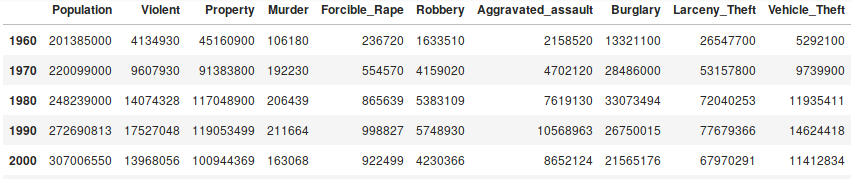

</details>


In [ ]:
# Votre code





## Exercice 3 — Exploration du fichier des prénoms
Le fichier des prénoms contient des données sur les prénoms attribués aux enfants nés en France entre 1900 et 2021. Les données sont disponibles sur le site de l'INSEE : 

<a href="https://www.insee.fr/fr/statistiques/2540004?sommaire=4767262"
    target="_blank"
    rel="noopener noreferrer">
Fichier des prénoms - INSEE
</a>


L'objectif de cet exercice est d'explorer, nettoyer et analyser ce jeu de données
afin d'obtenir différentes statistiques descriptives sur les prénoms.


<h3>Partie 1 : Import et exploration des données</h3>

<ol>
    <li>Importez les données directement depuis l'URL fournie dans un DataFrame.</li>
    <li>Affichez un échantillon des données et repérez d'éventuelles anomalies.</li>
    <li>Utilisez la méthode <code>info()</code> pour examiner la structure du DataFrame.</li>
    <li>Identifiez les variables dont le type semble inadapté ainsi que les éventuelles valeurs manquantes.</li>
</ol>

<h3>Partie 2 : Nettoyage des données</h3>

<ol>
    <li>Affichez les ligness pour lesquelles la colonne des prénoms contient une valeur manquante.</li>
    <li>Repérez la modalité <code>_PRENOMS_RARES</code> dans la colonne des prénoms.</li>
    <li>Calculez la proportion d'observations concernées puis remplacez cette modalité par <code>np.nan</code>.</li>
    <li>Repérez les observations dont l'année de naissance est renseignée par <code>XXXX</code>.</li>
    <li>Calculez leur proportion puis convertissez ces valeurs en <code>np.nan</code>.</li>
    <li>Supprimez les ligness contenant des valeurs manquantes.</li>
    <li>Convertissez la colonne <code>annais</code> en type numérique.</li>
    <li>Convertissez la colonne <code>sexe</code> en type catégoriel.</li>
    <li>Vérifiez que le nettoyage a bien été appliqué à l'aide de la méthode <code>info()</code>.</li>
</ol>

<h3>Partie 3 : Statistiques descriptivess sur les naissances</h3>

<p>
    La documentation indique que les données peuvent être considérées comme
    quasi exhaustives à partir de 1946.
</p>

<ol>
    <li>Filtrez le DataFrame afin de ne conserver que les naissances à partir de 1946.</li>
    <li>Calculez le nombre total de naissances par sexe.</li>
    <li>Identifiez les cinq années ayant enregistré le plus grand nombre de naissances.</li>
</ol>

<h3>Partie 4 : Analyse des prénoms</h3>

<ol>
    <li>Calculez le nombre total de prénoms distincts présents dans le DataFrame.</li>
    <li>Comptez le nombre de personnes portant un prénom composé d'une seule lettre.</li>
    <li>
    Créez une fonction de <em>popularité</em> qui, pour un prénom donné,
    renvoie l'année où il a été le plus attribué ainsi que le nombre de naissances
    correspondant.
    </li>
    <li>
    Créez une fonction qui, pour un sexe donné, renvoie un DataFrame contenant
    le prénom le plus attribué pour chaque décennie.
    </li>
</ol>

  </div>
</details>

In [ ]:
# Votre code






## Exercice 4 — Empreinte carbone par habitant au niveau communal

  <p>
    L’objectif de cet exercice est de calculer une empreinte carbone par habitant
    au niveau communal. Pour cela, vous devrez combiner deux sources de données :
  </p>

  <ul>
    <li>
      Les populations légales au niveau des communes, issues du recensement de la population (<a href="https://www.insee.fr/fr/statistiques/6683037" target="_blank">source</a>).
    </li>
    <li>
      Les émissions de gaz à effet de serre estimées au niveau communal par l’ADEME (<a href="https://data.ademe.fr/data-fair/api/v1/datasets/igt-pouvoir-de-rechauffement-global/data-files/IGT%20-%20Pouvoir%20de%20r%C3%A9chauffement%20global.csv" target="_blank">source</a>).
    </li>
  </ul>

  <p>
    Cet exercice constitue une version simplifiée d’un <a href="https://pythonds.linogaliana.fr/content/manipulation/02b_pandas_TP.html" target="_blank">TP complet </a> proposé par Lino Galiana.
  </p>

  <h3>Partie 1 : Exploration des données sur les populations légales communales</h3>

  <ol>
    <li>Importez le fichier <code>communes.csv</code>.</li>
    <li>Utilisez les méthodes <code>.sample()</code>, <code>.info()</code> et <code>.describe()</code> afin d’obtenir un aperçu des données.</li>
    <li>Identifiez et supprimez les ligness correspondant aux communes sans population.</li>
    <li>Gardez uniquement la colonne <code>PTOT</code>.</li>
    <li>
      Les communes ayant les noms les plus longs sont-elles également les moins peuplées ?
      Pour répondre à cette question :
      <ul>
        <li>Créez une nouvelle variable contenant le nombre de caractères du nom de chaque commune à l’aide de <code>str.len()</code>.</li>
        <li>Calculez la corrélation entre cette variable et la population totale avec la méthode <code>corr()</code>.</li>
      </ul>
    </li>
  </ol>

  <h3>Partie 2 : Exploration des données sur les émissions communales</h3>

  <ol>
    <li>Importez les données d’émissions communales.</li>
    <li>Utilisez les méthodes <code>.sample()</code>, <code>.info()</code> et <code>.describe()</code> afin d’explorer le jeu de données.</li>
    <li>
      Vérifiez s’il existe des lignes contenant uniquement des valeurs manquantes
      pour les colonnes d’émissions à l’aide des méthodes <code>isnull()</code> et <code>all()</code>.
    </li>
    <li>Créez une nouvelle colonne contenant les émissions totales par commune.</li>
    <li>Affichez les 10 communes les plus émettrices et analysez les résultats obtenus.</li>
    <li>
      Calculez la corrélation entre les émissions totales et les différents postes sectoriels
      d’émissions à l’aide de la méthode <code>corrwith()</code>.
    </li>
    <li>
      Extrayez le numéro de département à partir du code commune dans une nouvelle variable.
    </li>
    <li>
      Calculez les émissions totales par département et affichez les 10 départements
      les plus émetteurs.
    </li>
    <li>
      Analysez si ces résultats sont cohérents avec les observations réalisées au niveau communal.
    </li>
  </ol>

  <h3>Partie 3 : Vérifications préalables pour la jointure des sources de données</h3>

  <p>
    Avant d’effectuer une jointure, il est nécessaire d’identifier une clé de jointure
    commune aux deux sources de données permettant d’identifier les unités statistiques.
  </p>

  <ol>
    <li>Vérifiez si la variable contenant les noms de commune contient des doublons.</li>
    <li>
      Filtrez les communes dont le nom est dupliqué et triez le résultat par code commune.
      Analysez si ces doublons sont problématiques.
    </li>
    <li>
      Vérifiez que les codes commune permettent d’identifier une commune de manière unique.
    </li>
    <li>
      Affichez les communes présentes dans les données communales mais absentes des données
      d’émissions, puis inversement. Interprétez les résultats.
    </li>
  </ol>

  <h3>Partie 4 : Calcul d’une empreinte carbone par habitant pour chaque commune</h3>

  <ol>
    <li>
      Effectuez une jointure entre les deux DataFramess à l’aide du code commune.
      Attention : les variables utilisées comme clé de jointure ne portent pas le même nom
      dans les deux sources.
    </li>
    <li>
      Calculez l’empreinte carbone par habitant pour chaque commune.
    </li>
    <li>
      Analysez les communes ayant les plus fortes empreintes carbone par habitant.
    </li>
  </ol>

  </div>
</details>

In [ ]:
# Votre code




